In [1]:
import importlib
import os
import sys
from pathlib import Path


def _project_root() -> Path:
    """Repo root: contains src/stabilizer_code.py and lib/TrapSIMD/grid_iontrap.py."""
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        if (base / "src" / "stabilizer_code.py").is_file() and (
            base / "lib" / "TrapSIMD" / "grid_iontrap.py"
        ).is_file():
            return base
    return cwd


PROJECT_ROOT = _project_root()
_root = str(PROJECT_ROOT)
if _root not in sys.path:
    sys.path.insert(0, _root)

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
import sinter
import src.sinter_numpy_compat  # NumPy 2: sinter expects int, not np.int64

from src.stabilizer_code import extract, to_qiskit, surface_code
from src.simulate import tostim

import lib.TrapSIMD.grid_iontrap as _grid_iontrap_mod

importlib.reload(_grid_iontrap_mod)
from lib.TrapSIMD.grid_iontrap import grid_compiler

In [2]:
path = str(PROJECT_ROOT / "QEC-Code")

In [3]:
def gen_noise_profile(base=10 ** (-4)):
    p_trans = 2 * base 
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        "2q-gate": 18.3 * base
    }
    return noise_profile 

In [4]:
def gen_noise_profile2(p_trans = 2 * 10 ** (-4)):
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        "2q-gate": 18.3 * 10 ** (-4)
    }
    return noise_profile 

In [5]:
# ~10 minute budget with adaptive stopping, same decoder workflow
noise_list = [2e-4, 1.5e-4, 1e-4]
d_list = [3, 5, 7]
tasks = []

D = 5
L = 3
CZ = 3
draw_flag = False

for d in d_list:
    code_name = "surface-code"
    stab_fname = os.path.join(path, f"{code_name}-{d}.stab")
    surface_code(stab_fname, d)

    qasm_fname = os.path.join(path, f"{code_name}-{d}.qasm")
    is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
    to_qiskit(qasm_fname, is_CSS, is_ordered, stabilizers, dataNum, iter=d * 3)

    qc = QuantumCircuit.from_qasm_file(qasm_fname)
    num_q = qc.num_qubits
    num_s = qc.num_clbits

    result_our_list, node_list = grid_compiler(D, L, CZ, qc, draw_flag)

    for p in noise_list:
        stim_circ = tostim(
            gen_noise_profile2(p), stabilizers, logicals, node_list, num_q, num_s
        )
        tasks.append(
            sinter.Task(
                circuit=stim_circ,
                json_metadata={"d": d, "r": d * 3, "p": p},
            )
        )

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=200_000,
    max_errors=200,
    print_progress=True,
)

Starting 4 workers...
9 tasks left:
  workers    decoder eta shots_left errors_left json_metadata     
        1 pymatching   ?     200000         200 d=3,r=9,p=0.0002  
        1 pymatching   ?     190511           0 d=3,r=9,p=0.00015 
        1 pymatching   ?     200000         200 d=3,r=9,p=0.0001  
        1 pymatching   ?     200000         200 d=5,r=15,p=0.0002 
        0 pymatching ?·∞     200000         200 d=5,r=15,p=0.00015
        0 pymatching ?·∞     200000         200 d=5,r=15,p=0.0001 
        0 pymatching ?·∞     200000         200 d=7,r=21,p=0.0002 
        0 pymatching ?·∞     200000         200 d=7,r=21,p=0.00015
        0 pymatching ?·∞     200000         200 d=7,r=21,p=0.0001 
5 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata     
        1 pymatching          ?     191535           0 d=5,r=15,p=0.00015
        1 pymatching [draining]     190511         -11 d=5,r=15,p=0.0001 
        1 pymatching          ?     200000         200 d=7

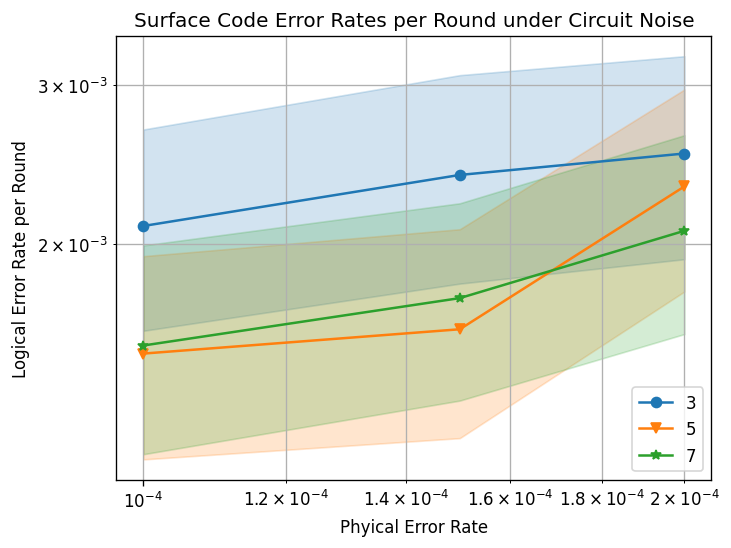

In [6]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
    failure_units_per_shot_func=lambda stats: stats.json_metadata['r'],
)
ax.loglog()
ax.set_title("Surface Code Error Rates per Round under Circuit Noise")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  